In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_path = "/content/drive/MyDrive/Breast Cancer/breast+cancer+wisconsin+diagnostic.zip"

print("File exists:", os.path.exists(zip_path))

File exists: True


In [4]:
extract_path = "/content/breast_cancer_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")

Files extracted successfully!


In [5]:
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

/content/breast_cancer_data/wdbc.names
/content/breast_cancer_data/wdbc.data


In [6]:
columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se",
    "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

data_file = None

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file == "wdbc.data":
            data_file = os.path.join(root, file)

print("Dataset path:", data_file)

Dataset path: /content/breast_cancer_data/wdbc.data


In [7]:
df = pd.read_csv(
    data_file,
    header=None,
    names=columns
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
df.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 569
Number of columns: 32


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [11]:
summary_statistics = df.drop(columns=["ID"]).describe().T

summary_statistics["median"] = df.drop(columns=["ID"]).median(numeric_only=True)

summary_statistics

,count,mean,std,min,25%,50%,75%,max,median
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,13.370000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,18.840000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,86.240000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,551.100000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.095870
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,0.092630
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,0.061540
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,0.033500
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0.179200
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,0.061540


In [12]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [16]:
print(df["Diagnosis"].value_counts())

Diagnosis
B    357
M    212
Name: count, dtype: int64


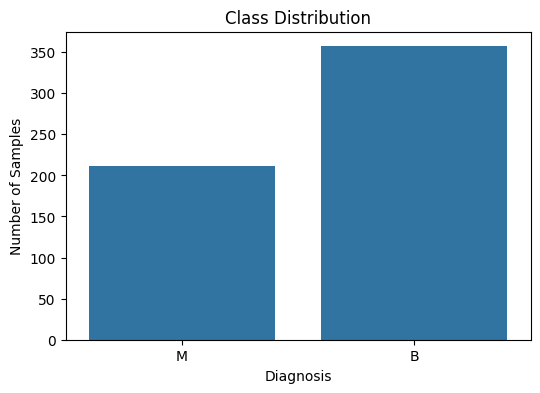

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Diagnosis")

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

In [18]:
df["Outcome"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

In [19]:
print(df[["Diagnosis", "Outcome"]].head(10))

  Diagnosis  Outcome
0         M        1
1         M        1
2         M        1
3         M        1
4         M        1
5         M        1
6         M        1
7         M        1
8         M        1
9         M        1


In [20]:
class_distribution = df["Outcome"].value_counts()

class_percentage = df["Outcome"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_distribution)

print("\nClass percentages:")
print(class_percentage)

Class counts:
Outcome
0    357
1    212
Name: count, dtype: int64

Class percentages:
Outcome
0    62.741652
1    37.258348
Name: proportion, dtype: float64


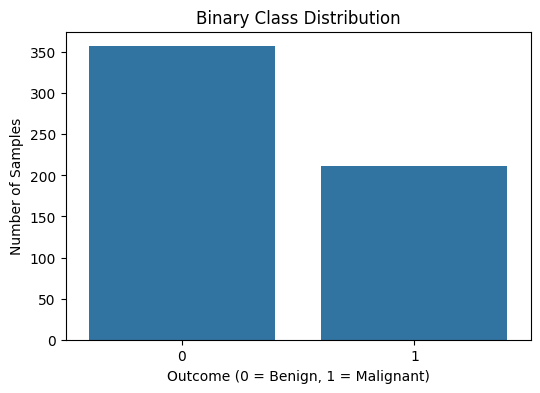

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Outcome")

plt.title("Binary Class Distribution")
plt.xlabel("Outcome (0 = Benign, 1 = Malignant)")
plt.ylabel("Number of Samples")

plt.show()

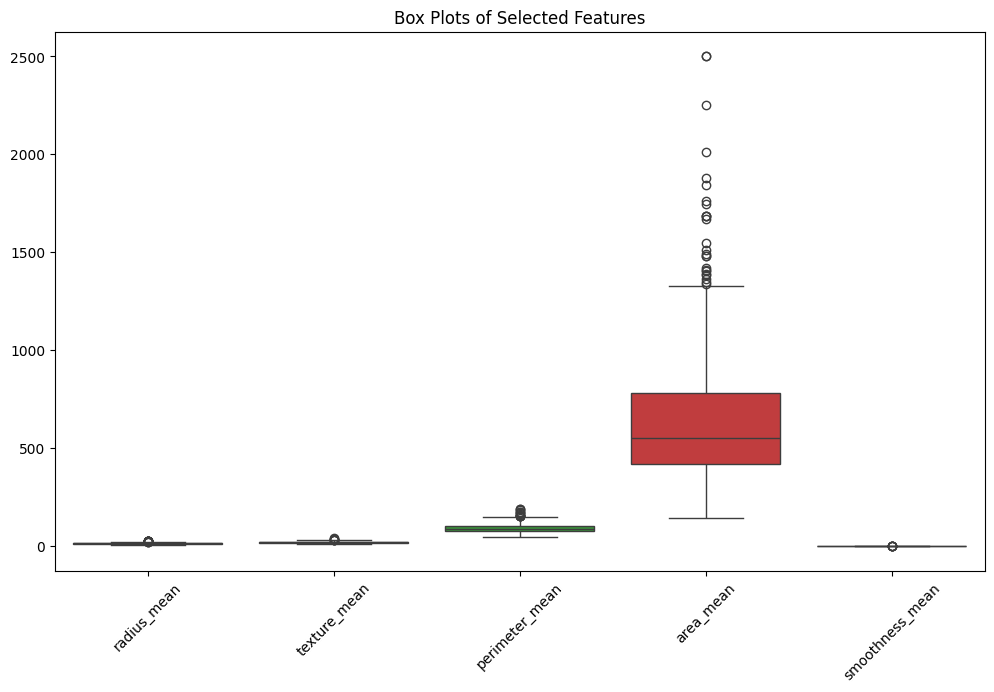

In [22]:
selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean"
]

plt.figure(figsize=(12, 7))

sns.boxplot(data=df[selected_features])

plt.title("Box Plots of Selected Features")
plt.xticks(rotation=45)

plt.show()

In [23]:
numeric_features = df.select_dtypes(include=np.number).drop(
    columns=["ID", "Outcome"]
)

Q1 = numeric_features.quantile(0.25)
Q3 = numeric_features.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (numeric_features < lower_bound) |
    (numeric_features > upper_bound)
).sum()

print("Outlier count for each feature:")
print(outlier_counts.sort_values(ascending=False))

Outlier count for each feature:
area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
symmetry_worst             23
concavity_se               22
texture_se                 20
concave_points_se          19
concavity_mean             18
radius_worst               17
compactness_worst          16
compactness_mean           16
symmetry_mean              15
fractal_dimension_mean     15
perimeter_worst            15
radius_mean                14
perimeter_mean             13
concavity_worst            12
concave_points_mean        10
texture_mean                7
smoothness_worst            7
smoothness_mean             6
texture_worst               5
concave_points_worst        0
dtype: int64


In [24]:
df_clean = df.copy()

for column in numeric_features.columns:
    df_clean[column] = df_clean[column].clip(
        lower=lower_bound[column],
        upper=upper_bound[column]
    )

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


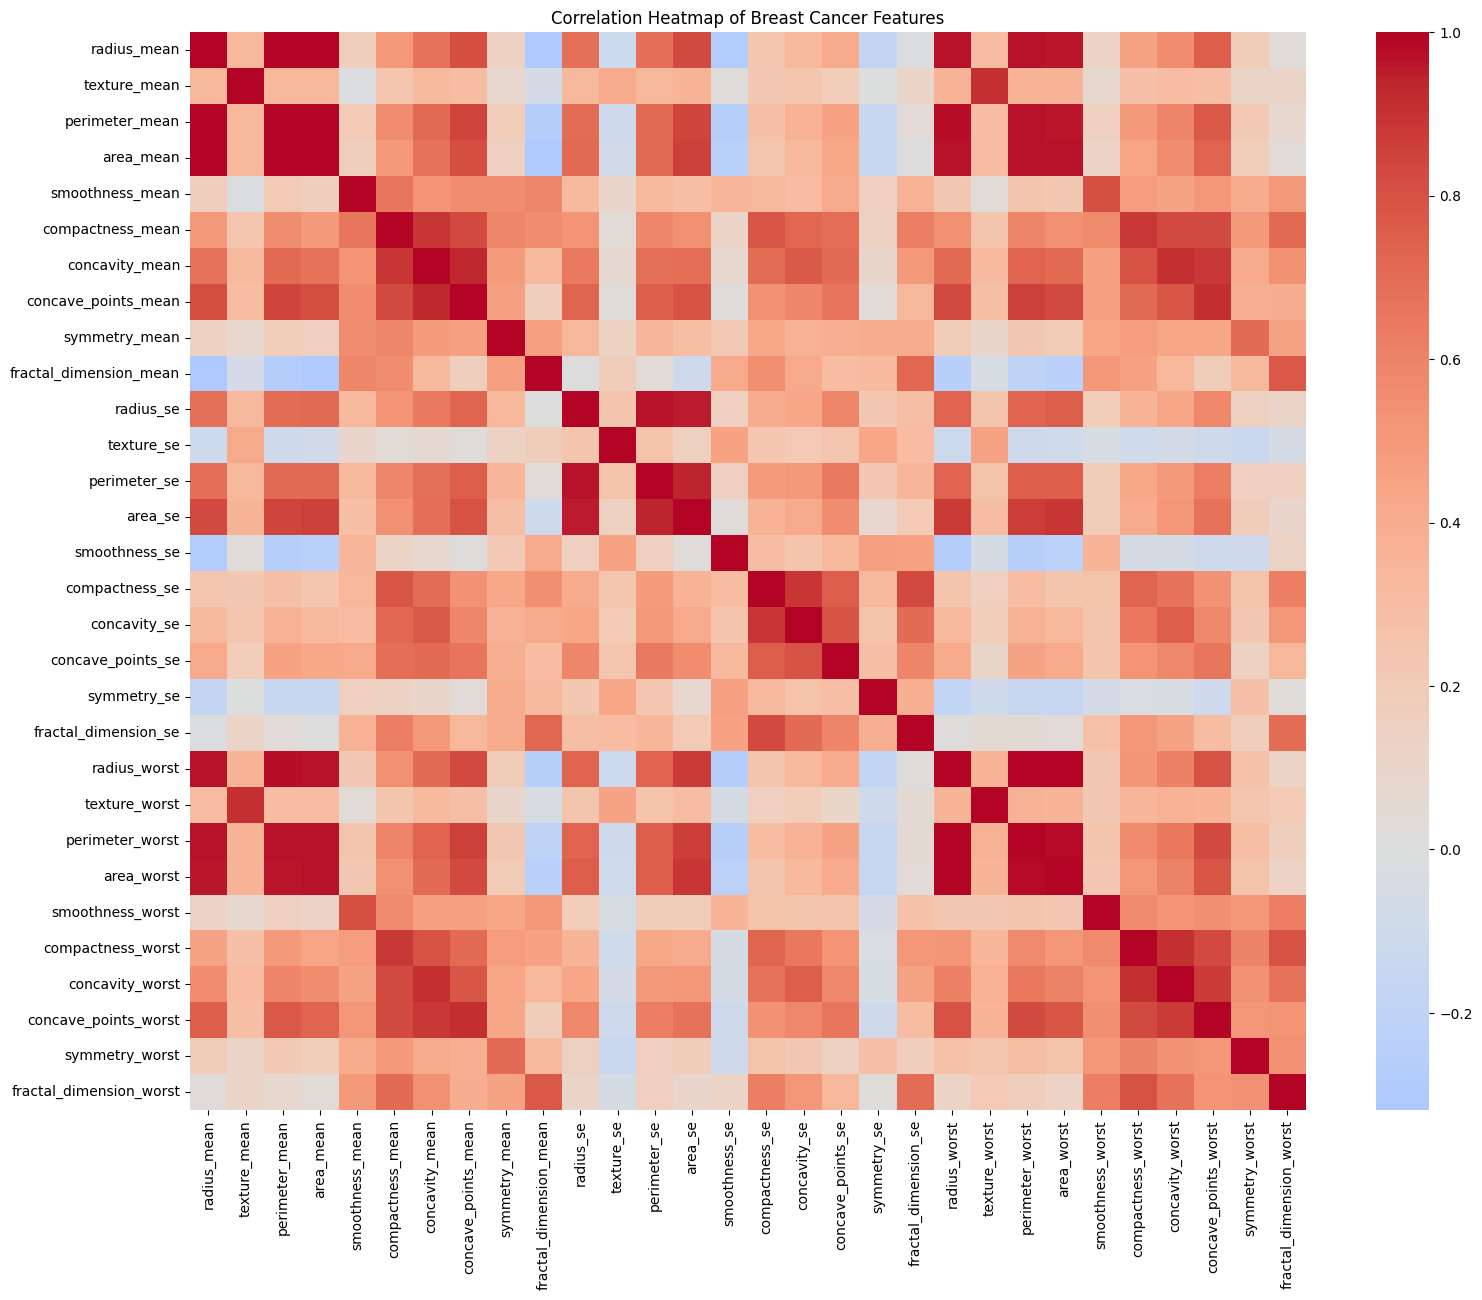

In [26]:
plt.figure(figsize=(18, 14))

correlation_matrix = df_clean[numeric_features.columns].corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Breast Cancer Features")

plt.show()


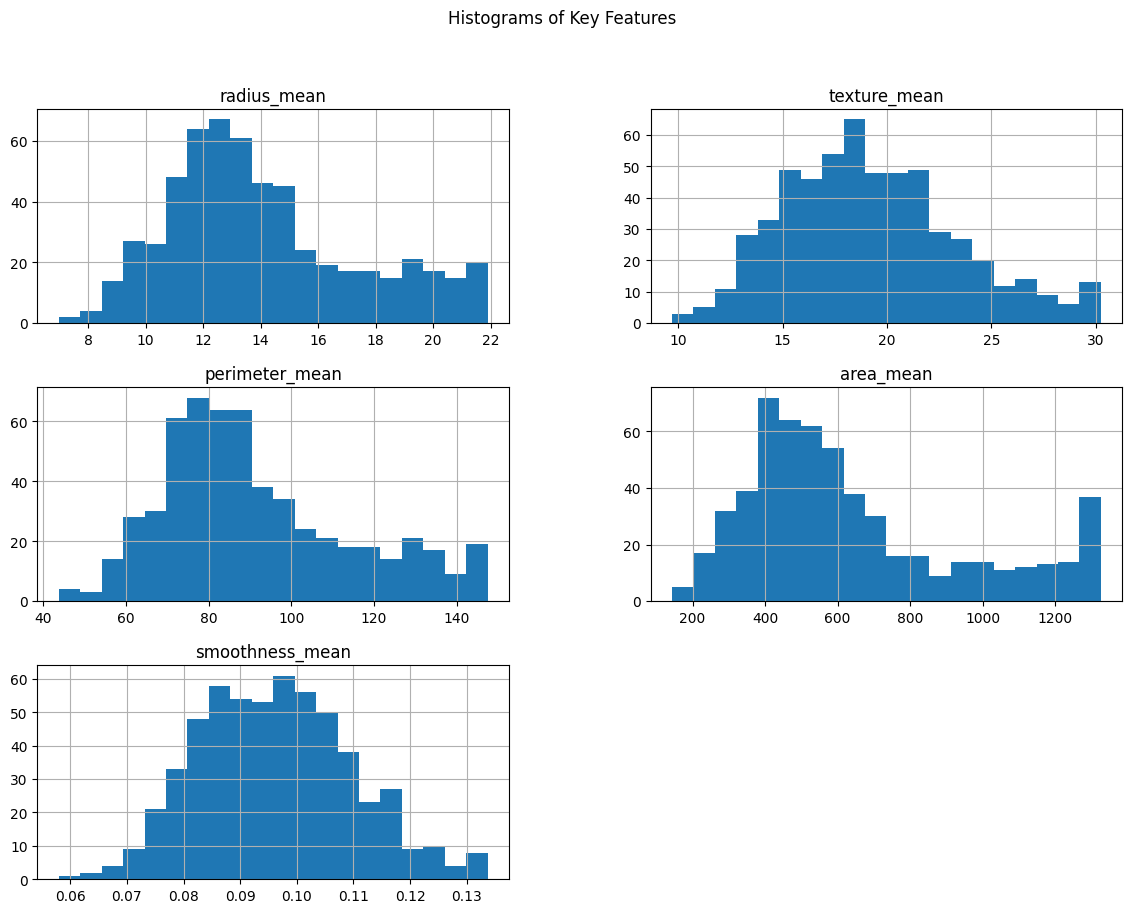

In [27]:
key_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean"
]

df_clean[key_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Histograms of Key Features")

plt.show()

In [28]:
X = df_clean.drop(columns=["ID", "Diagnosis", "Outcome"])

y = df_clean["Outcome"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


In [30]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
Outcome
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
X_train_scaled

array([[ 0.5758599 ,  0.92757617,  0.47493976, ..., -0.23574392,
         0.11410086,  0.06406519],
       [-0.52708403, -1.67970764, -0.55427311, ..., -0.32320788,
        -0.10944359, -0.99030026],
       [-0.36909477,  0.47821021, -0.39115258, ..., -0.89082504,
        -0.73573755, -0.12472958],
       ...,
       [-0.32438082,  1.38174819, -0.39201565, ..., -0.84289958,
        -1.07197796, -1.29136832],
       [ 0.03333072,  0.27635598,  0.03088943, ...,  0.27571059,
        -0.65075371, -0.30850654],
       [ 0.88587657,  0.38929822,  0.86763733, ...,  1.00657384,
        -0.48632845, -0.47095785]])

In [35]:
X_test_scaled

array([[-0.79834862, -2.05698281, -0.79204933, ..., -0.38805702,
         0.23972914,  0.10859817],
       [ 2.04247724,  1.00447302,  2.03709934, ...,  1.42292627,
         0.44295137, -0.31415157],
       [ 0.62057384, -0.79539387,  0.63029265, ...,  0.14391558,
         0.49283319,  0.38269556],
       ...,
       [ 0.1317014 , -0.00960418,  0.11029201, ..., -0.29280517,
        -0.76714462, -0.55626047],
       [ 0.30757624, -0.64880925,  0.30577773, ...,  0.14541325,
         0.97687158,  0.87193116],
       [ 0.59076455,  0.06488964,  0.53535477, ...,  0.54678897,
        -0.43644663, -1.23115471]])

In [36]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [37]:
y_pred = logistic_model.predict(X_test_scaled)

y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9649122807017544
Accuracy: 96.49%


In [40]:
precision = precision_score(
    y_test,
    y_pred,
    average=None,
    labels=[0, 1]
)

recall = recall_score(
    y_test,
    y_pred,
    average=None,
    labels=[0, 1]
)

f1 = f1_score(
    y_test,
    y_pred,
    average=None,
    labels=[0, 1]
)

results = pd.DataFrame({
    "Class": ["Benign (0)", "Malignant (1)"],
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

results

,Class,Precision,Recall,F1-Score
0,Benign (0),0.959459,0.986111,0.972603
1,Malignant (1),0.975000,0.928571,0.951220


In [41]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [42]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[71  1]
 [ 3 39]]


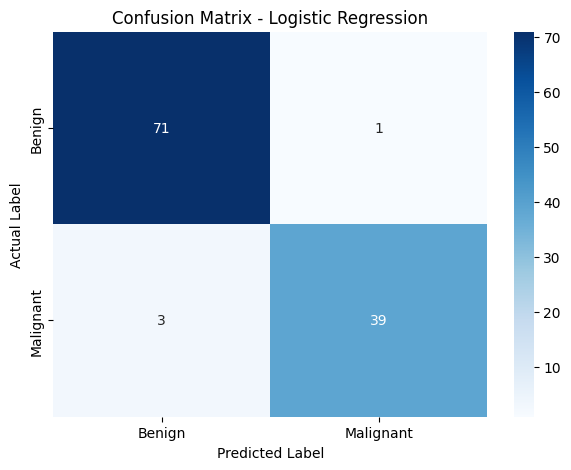

In [43]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [44]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

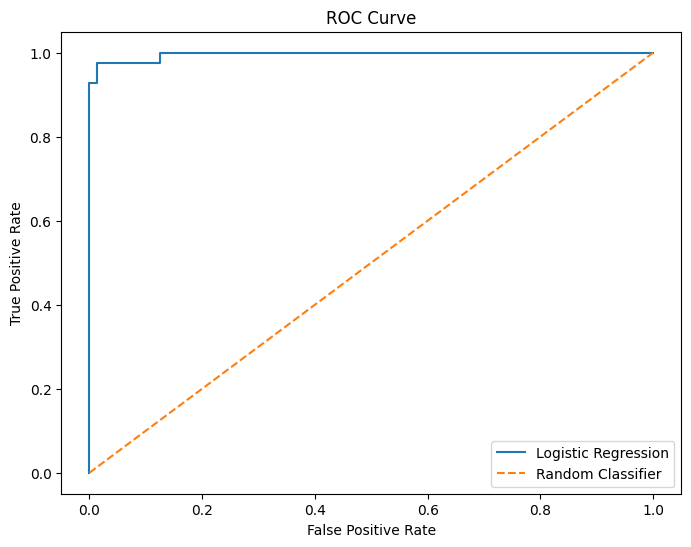

In [45]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [46]:
auc_score = roc_auc_score(
    y_test,
    y_pred_proba
)

print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.9964


In [48]:
accuracy = accuracy_score(y_test, y_pred)

precision_malignant = precision_score(y_test, y_pred, pos_label=1)
recall_malignant = recall_score(y_test, y_pred, pos_label=1)
f1_malignant = f1_score(y_test, y_pred, pos_label=1)

auc = roc_auc_score(y_test, y_pred_proba)

print(" LOGISTIC REGRESSION RESULTS ")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (M)      : {precision_malignant:.4f}")
print(f"Recall (M)         : {recall_malignant:.4f}")
print(f"F1-Score (M)       : {f1_malignant:.4f}")
print(f"ROC-AUC            : {auc:.4f}")

 LOGISTIC REGRESSION RESULTS 
Accuracy           : 0.9649
Precision (M)      : 0.9750
Recall (M)         : 0.9286
F1-Score (M)       : 0.9512
ROC-AUC            : 0.9964


In [49]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = abs(
    coefficients["Coefficient"]
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
21,texture_worst,1.468068,1.468068
13,area_se,1.160746,1.160746
28,symmetry_worst,1.041055,1.041055
15,compactness_se,-1.024224,1.024224
7,concave_points_mean,0.900704,0.900704
10,radius_se,0.874900,0.874900
26,concavity_worst,0.845184,0.845184
23,area_worst,0.803073,0.803073
6,concavity_mean,0.765327,0.765327
19,fractal_dimension_se,-0.709758,0.709758


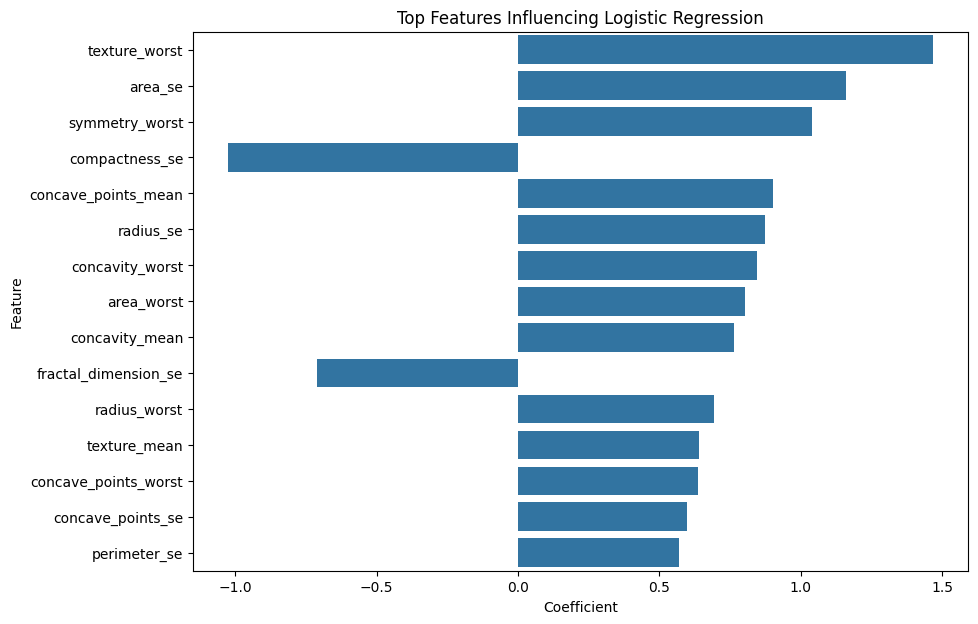

In [50]:
top_features = coefficients.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Influencing Logistic Regression")

plt.show()